In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("steam_cleaned.csv")

print("Shape:", df.shape)
print(df.head())
print(df.describe())

Shape: (27075, 22)
                        name release_date  english         developer  \
0             Counter-Strike   2000-11-01        1             Valve   
1      Team Fortress Classic   1999-04-01        1             Valve   
2              Day of Defeat   2003-05-01        1             Valve   
3         Deathmatch Classic   2001-06-01        1             Valve   
4  Half-Life: Opposing Force   1999-11-01        1  Gearbox Software   

  publisher          platforms  required_age  \
0     Valve  windows;mac;linux             0   
1     Valve  windows;mac;linux             0   
2     Valve  windows;mac;linux             0   
3     Valve  windows;mac;linux             0   
4     Valve  windows;mac;linux             0   

                                          categories  genres  \
0  Multi-player;Online Multi-Player;Local Multi-P...  Action   
1  Multi-player;Online Multi-Player;Local Multi-P...  Action   
2              Multi-player;Valve Anti-Cheat enabled  Action   
3  

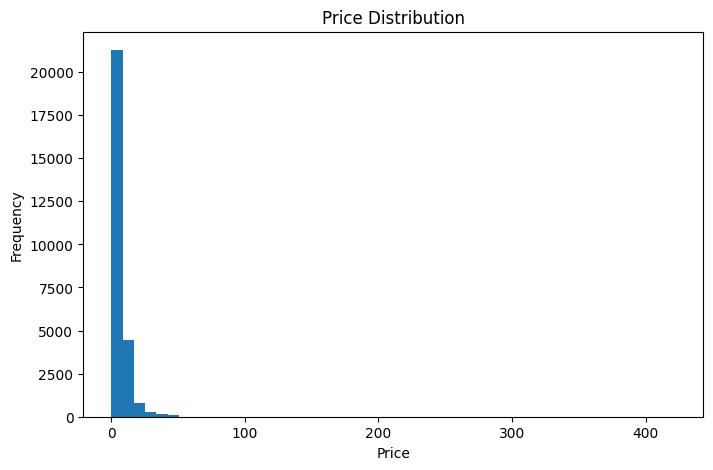

In [3]:
plt.figure(figsize=(8,5))
plt.hist(df["price"].dropna(), bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Most games appear to be concentrated in the lower price range, while a smaller number of games are sold at much higher prices.

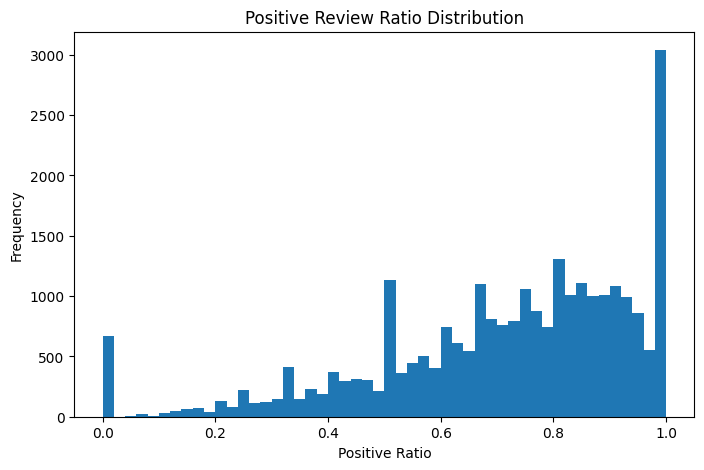

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df["positive_ratio"].dropna(), bins=50)
plt.title("Positive Review Ratio Distribution")
plt.xlabel("Positive Ratio")
plt.ylabel("Frequency")
plt.show()

The distribution of positive review ratio is skewed toward higher values, which suggests that many games receive mostly positive feedback.

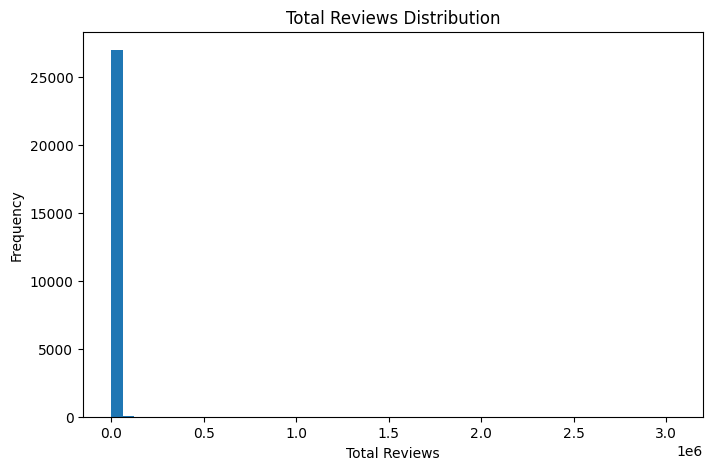

In [5]:
plt.figure(figsize=(8,5))
plt.hist(df["total_reviews"].dropna(), bins=50)
plt.title("Total Reviews Distribution")
plt.xlabel("Total Reviews")
plt.ylabel("Frequency")
plt.show()

Most games have relatively few reviews, while a small number of games have extremely high review counts.

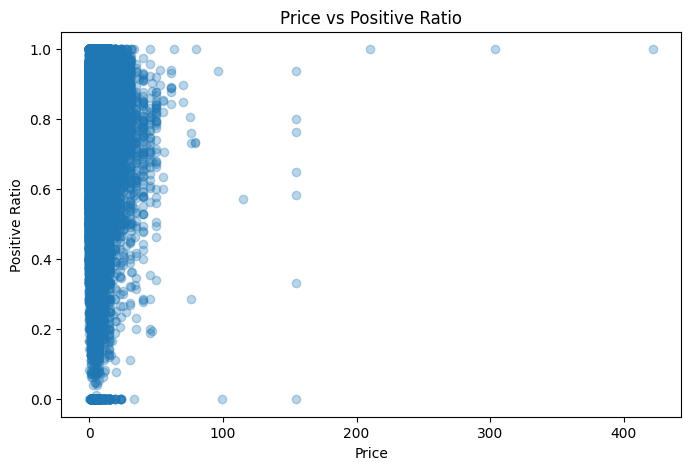

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(df["price"], df["positive_ratio"], alpha=0.3)
plt.title("Price vs Positive Ratio")
plt.xlabel("Price")
plt.ylabel("Positive Ratio")
plt.show()

There does not seem to be a very strong linear relationship between price and positive review ratio, although some patterns may still exist in certain price ranges.

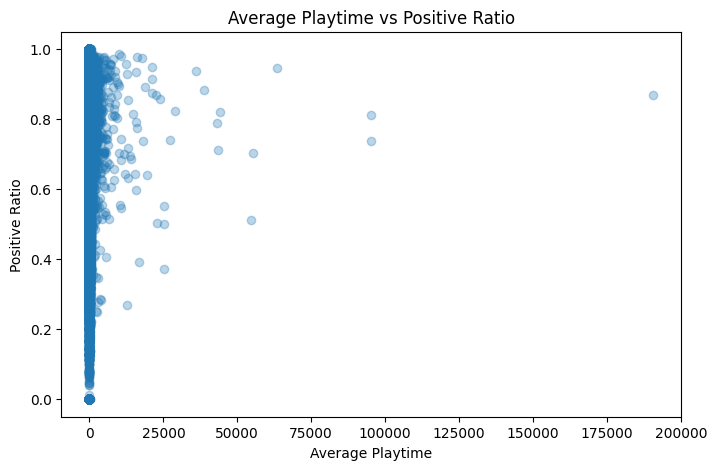

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(df["average_playtime"], df["positive_ratio"], alpha=0.3)
plt.title("Average Playtime vs Positive Ratio")
plt.xlabel("Average Playtime")
plt.ylabel("Positive Ratio")
plt.show()

Games with higher playtime may sometimes have strong review ratios, but the relationship does not appear perfectly clear from the scatterplot alone.

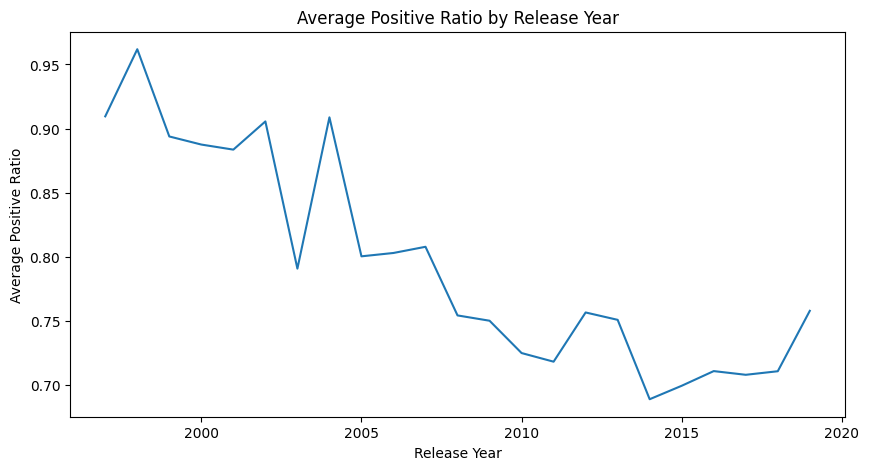

In [8]:
yearly = df.groupby("release_year")["positive_ratio"].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values)
plt.title("Average Positive Ratio by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Positive Ratio")
plt.show()

The average positive review ratio changes over release years, which may suggest differences in user expectations or market conditions over time.

In [9]:
numeric_cols = ["price", "positive_ratings", "negative_ratings", "average_playtime", "total_reviews", "positive_ratio", "release_year", "game_age"]
corr = df[numeric_cols].corr()

print(corr)

                     price  positive_ratings  negative_ratings  \
price             1.000000          0.036110          0.051259   
positive_ratings  0.036110          1.000000          0.762804   
negative_ratings  0.051259          0.762804          1.000000   
average_playtime  0.049242          0.157898          0.161140   
total_reviews     0.040363          0.992340          0.836842   
positive_ratio    0.076455          0.030240          0.000776   
release_year     -0.057292         -0.064384         -0.034860   
game_age          0.057292          0.064384          0.034860   

                  average_playtime  total_reviews  positive_ratio  \
price                     0.049242       0.040363        0.076455   
positive_ratings          0.157898       0.992340        0.030240   
negative_ratings          0.161140       0.836842        0.000776   
average_playtime          1.000000       0.164463        0.020407   
total_reviews             0.164463       1.000000        0.0

The correlation table helps identify which numerical variables move together and which ones may be useful in later analysis.

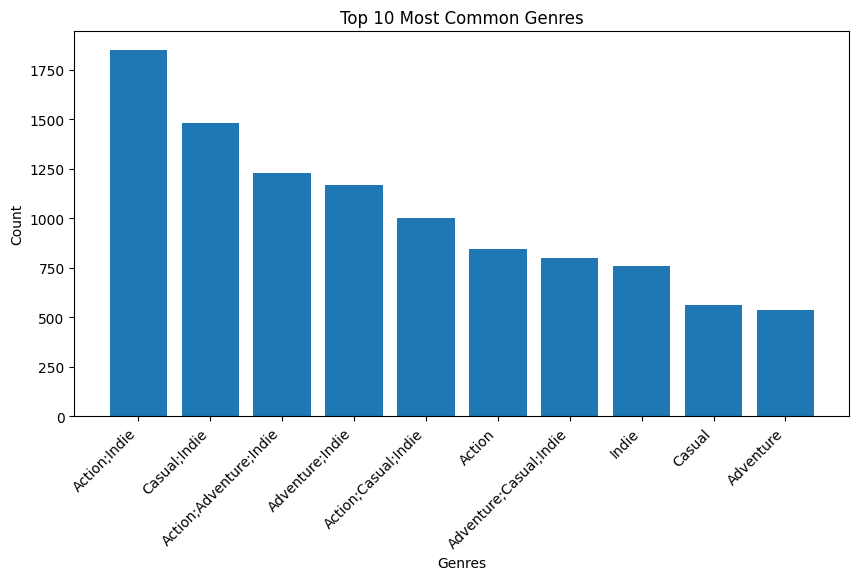

In [10]:
top_genres = df["genres"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_genres.index, top_genres.values)
plt.title("Top 10 Most Common Genres")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

Some genres are much more common than others, which may affect the overall distribution of success-related variables.